# CNN - NSAC

In [1]:
# Connect to Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import pandas as pd

# Read data from Google Drive.
# Data is already clean.

file_path = "/content/drive/MyDrive/Doutorado CAV 2024/Análises no Colab/JSTARS_153_samples.csv"
data = pd.read_csv(file_path, decimal=',')

# Separate response and predictor variables

X = data.iloc[:, 14:221]  # Spectral bands
y = data['V_hectare']     # Volume to be predicted

In [3]:
X.head()

,Band 1,Band 2,Band 3,Band 4,Band 5,Band 6,Band 7,Band 8,Band 9,Band 10,...,Band 198,Band 199,Band 200,Band 201,Band 202,Band 203,Band 204,Band 205,Band 206,Band 207
0,0.0151,0.0103,0.0087,0.0127,0.0118,0.0105,0.0124,0.0118,0.0132,0.0129,...,0.0274,0.0262,0.0282,0.0244,0.0253,0.0201,0.0208,0.0193,0.0188,0.0105
1,0.0141,0.0079,0.0097,0.0129,0.0105,0.0111,0.0114,0.0122,0.0132,0.0127,...,0.0273,0.0257,0.0246,0.0230,0.0252,0.0205,0.0227,0.0188,0.0203,0.0125
2,0.0102,0.0074,0.0081,0.0094,0.0096,0.0107,0.0109,0.0101,0.0118,0.0127,...,0.0275,0.0256,0.0280,0.0234,0.0224,0.0196,0.0215,0.0175,0.0183,0.0144
3,0.0128,0.0108,0.0105,0.0108,0.0103,0.0122,0.0122,0.0120,0.0126,0.0126,...,0.0276,0.0241,0.0281,0.0243,0.0221,0.0220,0.0204,0.0177,0.0187,0.0138
4,0.0128,0.0106,0.0095,0.0103,0.0095,0.0126,0.0130,0.0110,0.0120,0.0138,...,0.0267,0.0254,0.0251,0.0251,0.0226,0.0192,0.0208,0.0170,0.0187,0.0123


In [4]:
y.head()

,V_hectare
0,359.184
1,377.143
2,343.643
3,320.322
4,380.408


In [6]:
!pip install tensorflow

Shape of X_train_cnn after reshape: (122, 207, 1)
Shape of X_test_cnn after reshape: (31, 207, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 207, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 207, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 103, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 103, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 51, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6528)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 196)            │     1,279,684 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 196)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        12,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,319,493 (5.03 MB)

 Trainable params: 1,319,493 (5.03 MB)

 Non-trainable params: 0 (0.00 B)


Starting CNN training...
Training time: 64.4429 seconds

Training completed. Best model weights (based on validation loss) were from epoch 151.

Evaluating model on the training set...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
R² (CNN Train): 0.672
RMSE (CNN Train): 64.92
MAE (CNN Train): 51.34
RRMSE (CNN Train): 15.12%

Evaluating model on the test set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Prediction time on test set: 0.1488 seconds
R² (CNN Test): 0.582
RMSE (CNN Test): 69.14
MAE (CNN Test): 55.22
RRMSE (CNN Test): 16.60%


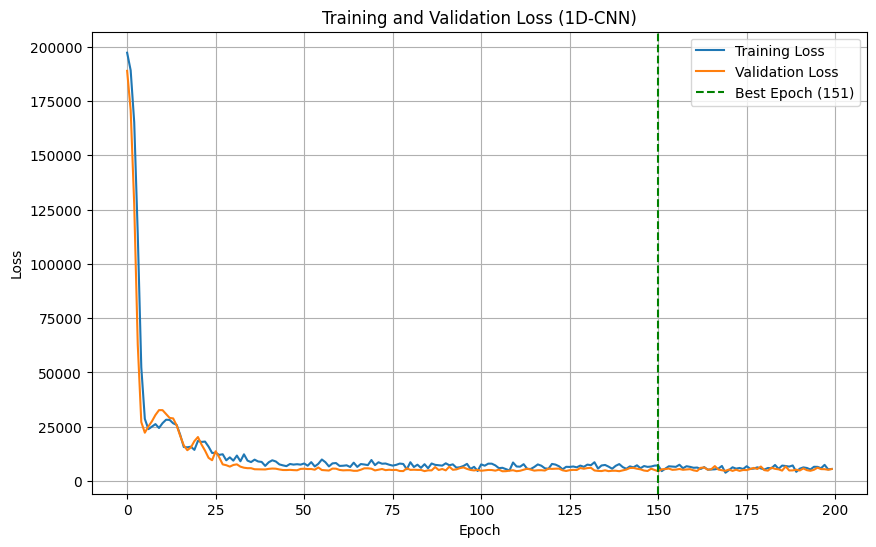

In [2]:
# 1D-CNN Training for Regression

import numpy as np
import tensorflow as tf
import random
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==============================================================================
# 1. Data Preprocessing
# ==============================================================================

# Set a random seed for reproducibility across different runs
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the predictor variables (X_train, X_test - spectral reflectances)
# using StandardScaler.
# The scaler is fitted only on the training data to prevent data leakage.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Reshape the data for 1D CNN input (Conv1D expects 3 dimensions)
# The required format is (n_samples, n_timesteps, n_features).
# Here, n_timesteps corresponds to the number of spectral bands (207),
# and n_features is 1, as each band is treated as a single feature per timestep.
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print(f"Shape of X_train_cnn after reshape: {X_train_cnn.shape}")
print(f"Shape of X_test_cnn after reshape: {X_test_cnn.shape}")


# ==============================================================================
# 2. 1D CNN Model Definition
# ==============================================================================

def build_cnn_model(input_shape):
    """
    Builds a 1D Convolutional Neural Network (CNN) model for regression.

    Args:
        input_shape (tuple): Shape of the input data (timesteps, features).

    Returns:
        tf.keras.Model: Compiled Keras model.
    """
    inputs = tf.keras.Input(shape=input_shape)

    # First Convolutional Block: Conv1D -> MaxPooling1D
    x = layers.Conv1D(filters=64, kernel_size=5, activation='relu', padding='same',
                      kernel_regularizer=keras.regularizers.l2(0.001))(inputs)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # Second Convolutional Block: Conv1D -> MaxPooling1D
    x = layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same',
                      kernel_regularizer=keras.regularizers.l2(0.001))(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # Flatten the output to feed into Dense layers
    x = layers.Flatten()(x)

    # Dense Layers with Dropout for regularization
    x = layers.Dense(units=196, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(units=64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(units=32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(x)

    # Output layer for regression (1 neuron, linear activation)
    outputs = layers.Dense(units=1, activation='linear')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    return model

# Define callbacks for optimized training. These are currently commented out
# in model.fit, but can be enabled by uncommenting the 'callbacks' parameter.
callbacks = [
    EarlyStopping(
        monitor='val_loss', # Monitor validation loss
        patience=50,        # Number of epochs with no improvement after which training will be stopped
        min_delta=1e-4,     # Minimum change in the monitored quantity to qualify as an improvement
        restore_best_weights=True, # Restore model weights from the epoch with the best value of the monitored quantity
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', # Monitor validation loss
        factor=0.5,         # Factor by which the learning rate will be reduced (new_lr = lr * factor)
        patience=40,        # Number of epochs with no improvement after which learning rate will be reduced
        min_lr=1e-6,        # Lower bound on the learning rate
        verbose=1
    )
]

# Instantiate and compile the CNN model
# The input_shape is derived from the number of spectral bands and a single feature channel.
input_shape = (X_train_scaled.shape[1], 1)
cnn_model = build_cnn_model(input_shape)

# Compile the model with Adam optimizer and Mean Squared Error (MSE) loss for regression.
cnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Display the model's architecture summary
cnn_model.summary()

# ==============================================================================
# 3. Model Training
# ==============================================================================

print("\nStarting CNN training...")
start_train_time = time.perf_counter()
history = cnn_model.fit(
    X_train_cnn, y_train,
    epochs=200,            # Number of epochs to train for
    batch_size=32,         # Number of samples per gradient update
    validation_split=0.2,  # Fraction of the training data to be used as validation data
    # callbacks=callbacks, # Uncomment to enable EarlyStopping and ReduceLROnPlateau
    verbose=0              # Set to 1 or 2 for progress bar during training
)
end_train_time = time.perf_counter()
print(f"Training time: {end_train_time - start_train_time:.4f} seconds")

# Identify the epoch with the best validation loss
best_epoch_index = np.argmin(history.history['val_loss'])
best_epoch = best_epoch_index + 1 # Convert 0-indexed to 1-indexed epoch number
print(f"\nTraining completed. Best model weights (based on validation loss) were from epoch {best_epoch}.")
# Note: If EarlyStopping is active and `restore_best_weights=True`, the model
# will automatically revert to these best weights.


# ==============================================================================
# 4. Model Evaluation
# ==============================================================================

print("\nEvaluating model on the training set...")
train_predictions_cnn = cnn_model.predict(X_train_cnn)

# Calculate and print regression metrics for the training set
r2_train_cnn = r2_score(y_train, train_predictions_cnn)
rmse_train_cnn = np.sqrt(mean_squared_error(y_train, train_predictions_cnn))
mae_train_cnn = mean_absolute_error(y_train, train_predictions_cnn)
rrmse_train_cnn = (rmse_train_cnn / np.mean(y_train)) * 100

print(f"R\u00b2 (CNN Train): {r2_train_cnn:.3f}")
print(f"RMSE (CNN Train): {rmse_train_cnn:.2f}")
print(f"MAE (CNN Train): {mae_train_cnn:.2f}")
print(f"RRMSE (CNN Train): {rrmse_train_cnn:.2f}%")


print("\nEvaluating model on the test set...")
start_pred_time = time.perf_counter()
test_predictions_cnn = cnn_model.predict(X_test_cnn)
end_pred_time = time.perf_counter()
print(f"Prediction time on test set: {end_pred_time - start_pred_time:.4f} seconds")

# Calculate and print regression metrics for the test set
r2_test_cnn = r2_score(y_test, test_predictions_cnn)
rmse_test_cnn = np.sqrt(mean_squared_error(y_test, test_predictions_cnn))
mae_test_cnn = mean_absolute_error(y_test, test_predictions_cnn)
rrmse_test_cnn = (rmse_test_cnn / np.mean(y_test)) * 100

print(f"R\u00b2 (CNN Test): {r2_test_cnn:.3f}")
print(f"RMSE (CNN Test): {rmse_test_cnn:.2f}")
print(f"MAE (CNN Test): {mae_test_cnn:.2f}")
print(f"RRMSE (CNN Test): {rrmse_test_cnn:.2f}%")


# Plot the training and validation loss history
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
# Highlight the epoch with the best validation loss
plt.axvline(x=best_epoch_index, color='green', linestyle='--',
            label=f'Best Epoch ({best_epoch})')
plt.title('Training and Validation Loss (1D-CNN)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Metrics - Observed vs Predict

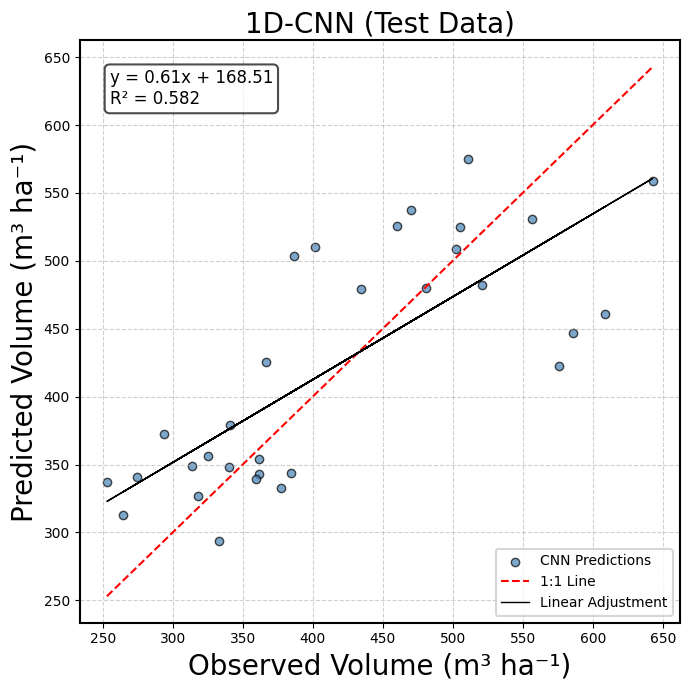

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Create a scatter plot of observed vs. predicted values for the test data
plt.figure(figsize=(7, 7))
plt.scatter(y_test, test_predictions_cnn, color='steelblue', edgecolor='k', alpha=0.7, label='CNN Predictions')

# Plot the 1:1 line (perfect prediction scenario)
min_val = min(y_test.min(), test_predictions_cnn.min())
max_val = max(y_test.max(), test_predictions_cnn.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='1:1 Line', linewidth=1.5)

# Fit a simple linear regression line to visualize the trend of predictions
reg_line_cnn = LinearRegression()
reg_line_cnn.fit(y_test.values.reshape(-1, 1), test_predictions_cnn.reshape(-1, 1))
slope_cnn = reg_line_cnn.coef_[0][0]
intercept_cnn = reg_line_cnn.intercept_[0]
y_fit_cnn = reg_line_cnn.predict(y_test.values.reshape(-1, 1))

# Plot the fitted regression line
plt.plot(y_test, y_fit_cnn, color='black', linewidth=1, label='Linear Adjustment')

# Display the equation of the fitted line and the R² score on the plot
eq_text_cnn = f"y = {slope_cnn:.2f}x + {intercept_cnn:.2f}\nR² = {r2_test_cnn:.3f}"
plt.text(0.05, 0.95, eq_text_cnn, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top',
         # cor da borda da caixa da equação: preto
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, linewidth=1.5))

# Set plot labels, title, and other visual settings
plt.xlabel("Observed Volume (m³ ha⁻¹)").set_fontsize(20)
plt.ylabel("Predicted Volume (m³ ha⁻¹)").set_fontsize(20)
plt.title("1D-CNN (Test Data)").set_fontsize(20)
legend = plt.legend(frameon=True)
legend.get_frame().set_linewidth(1.5)
plt.grid(True, linestyle='--', alpha=0.6)

# Make plot border lines darker for better visibility
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

plt.tight_layout()
# Save the generated plot as a high-resolution PNG file
plt.savefig('grafico_cnn_teste.png', dpi=600)
plt.show()

# Permutation Importance (PIM)

Calculating Permutation Importance for CNN model...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Permutation Importance calculation for CNN done.


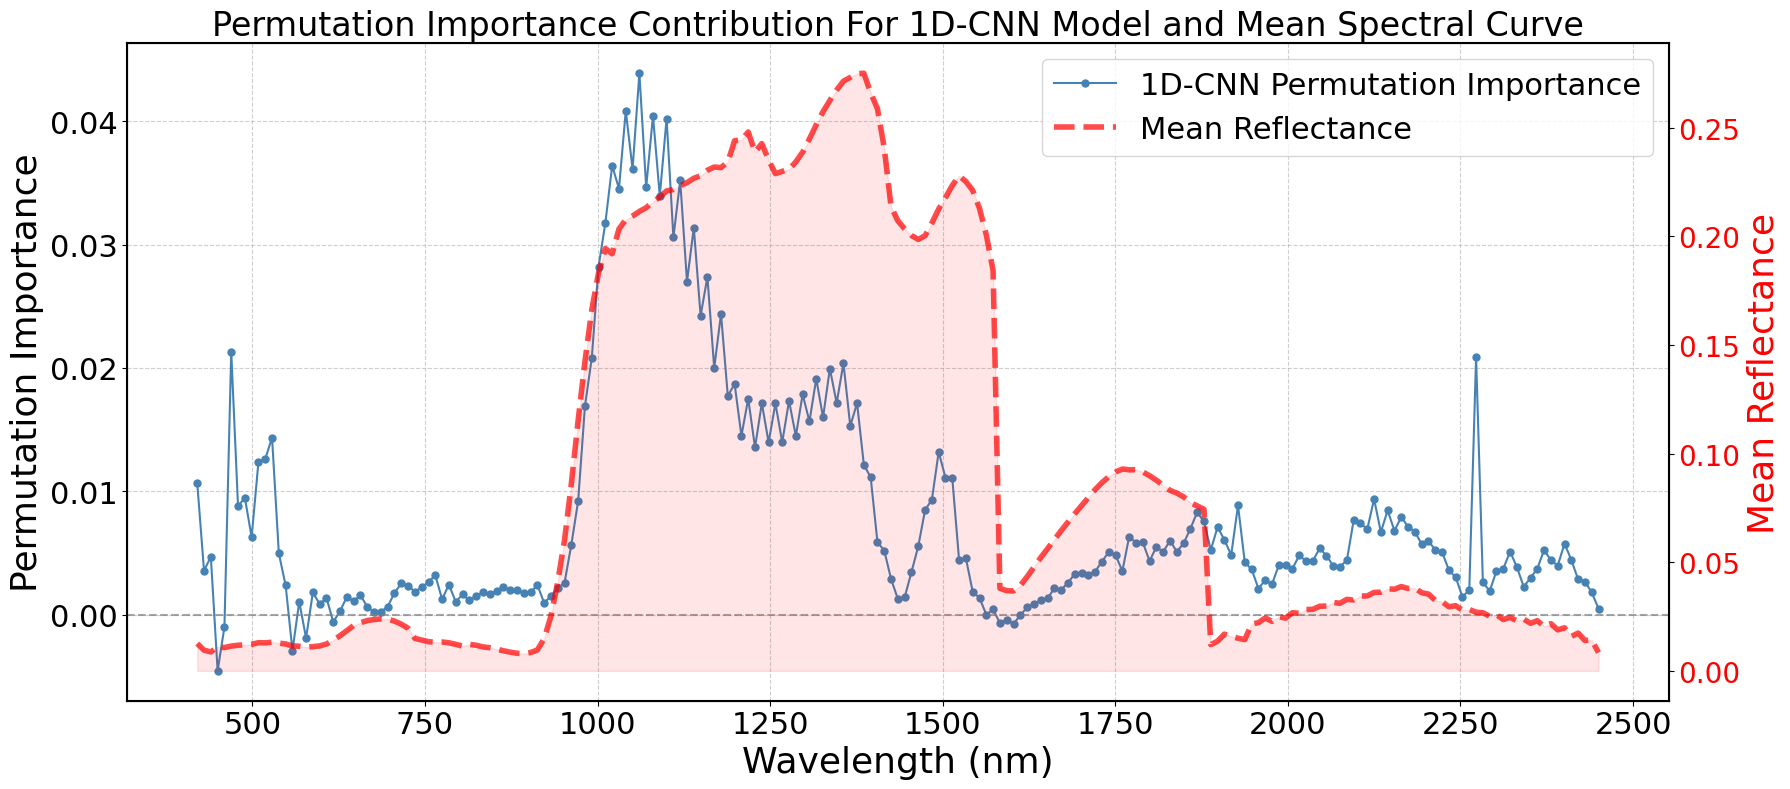

In [12]:
# Calculate Permutation Importance
# This process can be computationally intensive and may take a few minutes.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Kept for X.mean(axis=0) if X is a DataFrame
from sklearn.inspection import permutation_importance

# The variables `X`, `X_test_cnn`, `y_test`, and `cnn_model` are assumed to be
# defined and available from previous cells.

# Define a wrapper for the Keras model to make it compatible with scikit-learn's permutation_importance.
# Permutation importance expects a scikit-learn-like estimator, which typically takes 2D input.
# Our CNN model expects 3D input, so this wrapper reshapes the data accordingly before prediction.
class CNNPermutationWrapper:
    def __init__(self, cnn_model, original_input_shape_3d):
        self.cnn_model = cnn_model
        # Store the (timesteps, features) part of the original 3D input shape,
        # excluding the batch size dimension.
        self.target_shape_for_predict = original_input_shape_3d[1:]  # e.g., (207, 1) for spectral bands

    def predict(self, X_2d):
        # Reshape the 2D input from `permutation_importance` back to the 3D format
        # required by the CNN model (n_samples, n_timesteps, n_features).
        X_3d = X_2d.reshape(X_2d.shape[0], *self.target_shape_for_predict)
        return self.cnn_model.predict(X_3d)

    # A dummy `fit` method is often required to satisfy scikit-learn's estimator API,
    # even if no fitting is performed by the wrapper itself.
    def fit(self, X, y=None):
        return self


# 1. Prepare data for Permutation Importance calculation
# Flatten the `X_test_cnn` (3D) data into a 2D array, as `permutation_importance`
# expects a 2D feature matrix (n_samples, n_features).
X_test_cnn_flat = X_test_cnn.reshape(X_test_cnn.shape[0], -1)

# Instantiate the wrapper with the trained CNN model and its expected 3D input shape
# (excluding the batch size, which is handled dynamically).
cnn_wrapper = CNNPermutationWrapper(cnn_model, X_test_cnn.shape)

# 2. Calculate Permutation Importance for the CNN model
print("Calculating Permutation Importance for CNN model...")
perm_importance_cnn = permutation_importance(
    cnn_wrapper,  # The wrapped CNN model
    X_test_cnn_flat,  # The 2D flattened test data
    y_test,
    scoring='r2',  # Use R-squared as the scoring metric
    n_repeats=10,  # Number of times to permute a feature
    random_state=42,
    n_jobs=-1  # Use all available CPU cores for parallel processing
)
print("Permutation Importance calculation for CNN done.")

# 3. Prepare data for plotting the permutation importance and mean spectral curve

# Get the mean importance values for each feature (spectral band)
cnn_importances_mean = perm_importance_cnn.importances_mean

# Define EnMAP wavelengths (assuming 207 bands from 420nm to 2450nm)
enmap_wavelengths = np.linspace(420, 2450, X.shape[1])

# Calculate the mean spectral curve (mean reflectance for each band) from the original X data
mean_spectral_curve = X.mean(axis=0)

# 4. Create the plot with a secondary y-axis
fig, ax1 = plt.subplots(figsize=(18, 8))

# Plot CNN Permutation Importances on the primary y-axis (ax1)
ax1.plot(
    enmap_wavelengths,
    cnn_importances_mean,  # Importance values, ordered by band
    label='1D-CNN Permutation Importance',
    color='steelblue',
    linewidth=1.5,
    marker='o',
    markersize=5
)

# Add a horizontal line at y=0 to easily see positive/negative importances
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.7)
ax1.set_xlabel('Wavelength (nm)', fontsize=26)
ax1.set_ylabel('Permutation Importance', fontsize=26, color='black')
ax1.tick_params(axis='y', labelcolor='black', labelsize=22)
ax1.tick_params(axis='x', labelsize=22)
ax1.grid(True, linestyle='--', alpha=0.6)

# Create a second y-axis (ax2) to plot the mean spectral curve
ax2 = ax1.twinx()
ax2.plot(enmap_wavelengths, mean_spectral_curve, label='Mean Reflectance', color='red', linestyle='--', linewidth=4, alpha=0.7)
ax2.fill_between(enmap_wavelengths, mean_spectral_curve, color='red', alpha=0.1)  # Fill area under the mean reflectance curve
ax2.set_ylabel('Mean Reflectance', fontsize=26, color='red')
ax2.tick_params(axis='y', labelcolor='red', labelsize=20)

# Combine legends from both axes to display them in a single legend box
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', frameon=True, fontsize=22)

ax1.set_title('Permutation Importance Contribution For 1D-CNN Model and Mean Spectral Curve', fontsize=24)

# Make plot border lines darker for better visual appeal
ax1.spines['left'].set_edgecolor('black')
ax1.spines['left'].set_linewidth(1.5)
ax1.spines['bottom'].set_edgecolor('black')
ax1.spines['bottom'].set_linewidth(1.5)
ax2.spines['right'].set_edgecolor('black')
ax2.spines['right'].set_linewidth(1.5)
ax2.spines['top'].set_edgecolor('black')
ax2.spines['top'].set_linewidth(1.5)

plt.tight_layout()  # Adjust plot to prevent labels from overlapping
plt.savefig('grafico_importancia_cnn.png', dpi=600)  # Save the plot as a high-resolution PNG
plt.show()

# Cross-Validation

In [13]:
!pip install scikeras

In [14]:
!pip install --upgrade scikeras scikit-learn tensorflow numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.4/340.4 kB 8.0 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: numpy
    Found existing installation: numpy 2.1.3
    Uninstalling numpy-2.1.3:
      Successfully uninstalled numpy-2.1.3
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully unin

In [3]:
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import KFold, cross_val_predict, cross_val_score, cross_validate
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin

# Ensure y_train is a numpy array for consistent use in calculations
y_train_np = y_train.values

# Define a custom Reshaper transformer for the pipeline
# This class reshapes the 2D output from StandardScaler into the 3D input format
# required by the 1D CNN model (n_samples, n_timesteps, n_features).
class Reshaper(BaseEstimator, TransformerMixin):
    def __init__(self, target_shape):
        self.target_shape = target_shape

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        # X comes in as 2D from StandardScaler; reshape it for Conv1D
        return X.reshape(X.shape[0], *self.target_shape)

# KerasRegressor expects a callable that builds the model, not an already instantiated one.
# We pass a lambda function to KerasRegressor's build_fn to rebuild the cnn_model architecture
# for each fold. Loss and optimizer arguments are explicitly provided here.
keras_regressor = KerasRegressor(
    model=lambda: build_cnn_model(input_shape), # Callable that builds the model with the defined input_shape
    loss='mse',                                # Loss function for regression
    optimizer='adam',                          # Optimizer for training
    epochs=55,                                 # Number of epochs for each CV fold training
    batch_size=16,                             # Batch size for training within each fold
    verbose=0,                                 # Set to 0 to suppress output during CV folds
    random_state=42                            # Ensure reproducibility for KerasRegressor
)

# ==============================================================================
# 1. Create the Pipeline for the 1D CNN Model
# ==============================================================================
# The pipeline handles data scaling and reshaping before feeding it to the CNN.
# The input to the pipeline (`X_train`) is the raw 2D training data.
pipeline_cnn = Pipeline([
    ('scaler', StandardScaler()),
    ('reshaper', Reshaper(target_shape=(X_train.shape[1], 1))), # Reshape to (n_timesteps, n_features)
    ('cnn_model', keras_regressor)
])

# ==============================================================================
# 2. Perform Cross-Validation
# ==============================================================================

# Define KFold cross-validation strategy (10 folds, shuffled, reproducible)
cv_strategy = KFold(n_splits=10, shuffle=True, random_state=42)

# Perform cross-validation predictions for plotting consistency
# X_train is passed directly to the pipeline, which handles scaling and reshaping.
y_pred_cv_cnn_pipeline = cross_val_predict(pipeline_cnn, X_train, y_train_np, cv=cv_strategy, n_jobs=-1)

# Get fit and score times for the cross-validation process
# (using the same CV strategy)
result_cv_cnn_times = cross_validate(pipeline_cnn, X_train, y_train_np, cv=cv_strategy, n_jobs=-1)

print("Average training (fit) time: ", result_cv_cnn_times['fit_time'].mean())
print("Average test (score) time: ", result_cv_cnn_times['score_time'].mean())


# ==============================================================================
# 3. Evaluate Metrics from Cross-Validation Predictions (overall performance)
# ==============================================================================
# These metrics are calculated from the concatenated predictions across all folds.
r2_cv_cnn_pipeline = r2_score(y_train_np, y_pred_cv_cnn_pipeline)
rmse_cv_cnn_pipeline = np.sqrt(mean_squared_error(y_train_np, y_pred_cv_cnn_pipeline))
mse_cv_cnn_pipeline = mean_squared_error(y_train_np, y_pred_cv_cnn_pipeline)
mae_cv_cnn_pipeline = mean_absolute_error(y_train_np, y_pred_cv_cnn_pipeline)
rrmse_cv_cnn_pipeline = (rmse_cv_cnn_pipeline / np.mean(y_train_np)) * 100 # Relative RMSE

print(f"\nGlobal Metrics (from cross_val_predict across all folds):")
print(f"  Overall R² (CNN Pipeline CV): {r2_cv_cnn_pipeline:.3f}")
print(f"  Overall RMSE (CNN Pipeline CV): {rmse_cv_cnn_pipeline:.2f}")
print(f"  Overall MSE (CNN Pipeline CV): {mse_cv_cnn_pipeline:.2f}")
print(f"  Overall MAE (CNN Pipeline CV): {mae_cv_cnn_pipeline:.2f}")
print(f"  Overall RRMSE (CNN Pipeline CV): {rrmse_cv_cnn_pipeline:.2f}%")

# ==============================================================================
# 4. Calculate Fold-wise Metrics (mean and standard deviation)
# ==============================================================================
# Calculate R² and RMSE for each fold to get mean and standard deviation.
# The 'neg_root_mean_squared_error' scoring returns negative RMSE, so we negate it.
cv_scores_r2_cnn = cross_val_score(pipeline_cnn, X_train, y_train_np, cv=cv_strategy, scoring='r2', n_jobs=-1)
cv_scores_rmse_cnn = -cross_val_score(pipeline_cnn, X_train, y_train_np, cv=cv_strategy, scoring='neg_root_mean_squared_error', n_jobs=-1)

print(f"\nFold-wise Metrics (10-fold CV with Pipeline):")
print(f"  Mean R²: {cv_scores_r2_cnn.mean():.4f}")
print(f"  Std Dev (R²): {cv_scores_r2_cnn.std():.4f}")
print(f"  Range (R²): {cv_scores_r2_cnn.min():.4f} - {cv_scores_r2_cnn.max():.4f}")
print(f"  Mean RMSE: {cv_scores_rmse_cnn.mean():.4f}")
print(f"  Std Dev (RMSE): {cv_scores_rmse_cnn.std():.4f}")


Average training (fit) time:  36.49041352272034
Average test (score) time:  0.45507097244262695

Global Metrics (from cross_val_predict across all folds):
  Overall R² (CNN Pipeline CV): 0.526
  Overall RMSE (CNN Pipeline CV): 77.98
  Overall MSE (CNN Pipeline CV): 6080.10
  Overall MAE (CNN Pipeline CV): 62.96
  Overall RRMSE (CNN Pipeline CV): 18.16%


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Fold-wise Metrics (10-fold CV with Pipeline):
  Mean R²: 0.4577
  Std Dev (R²): 0.1884
  Range (R²): 0.1222 - 0.7834
  Mean RMSE: 75.6470
  Std Dev (RMSE): 17.7493


Cross-validation plot

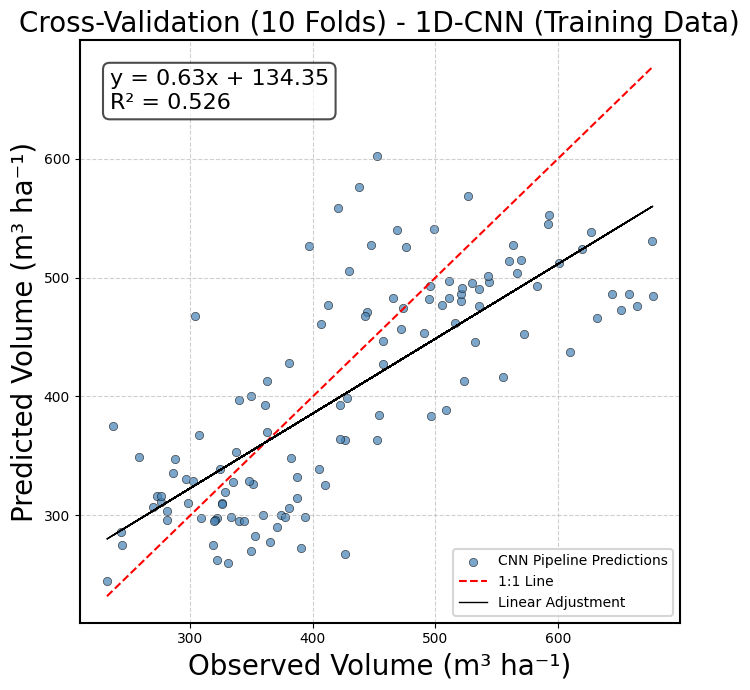

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import linregress

# ==============================================================================
# Plotting Observed vs. Predicted Values from Cross-Validation
# ==============================================================================

# Perform linear regression to get the equation for the adjustment line
slope_cnn_cv_pipeline, intercept_cnn_cv_pipeline, r_value_cnn_cv_pipeline, p_value_cnn_cv_pipeline, std_err_cnn_cv_pipeline = linregress(y_train_np, y_pred_cv_cnn_pipeline)

plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_train_np, y=y_pred_cv_cnn_pipeline, color="steelblue", edgecolor='k', alpha=0.7, label='CNN Pipeline Predictions')

# Plot the 1:1 line (perfect prediction scenario)
# This line visually represents where perfect predictions would lie.
min_val_cv = min(y_train_np.min(), y_pred_cv_cnn_pipeline.min())
max_val_cv = max(y_train_np.max(), y_pred_cv_cnn_pipeline.max())
plt.plot([min_val_cv, max_val_cv], [min_val_cv, max_val_cv], 'r--', label='1:1 Line', linewidth=1.5)

# Plot the linear adjustment line fitted to the observed vs. predicted data
plt.plot(y_train_np, intercept_cnn_cv_pipeline + slope_cnn_cv_pipeline * y_train_np, color='black', linewidth=1, label='Linear Adjustment')

# Display the equation of the fitted line and the R² score on the plot
eq_text_cnn_cv_pipeline = f"y = {slope_cnn_cv_pipeline:.2f}x + {intercept_cnn_cv_pipeline:.2f}\nR² = {r2_cv_cnn_pipeline:.3f}"
plt.text(0.05, 0.95, eq_text_cnn_cv_pipeline, transform=plt.gca().transAxes,
         fontsize=16, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, linewidth=1.5))

# Set plot labels, title, and other visual settings for clarity
plt.xlabel("Observed Volume (m³ ha⁻¹)").set_fontsize(20)
plt.ylabel("Predicted Volume (m³ ha⁻¹)").set_fontsize(20)
plt.title("Cross-Validation (10 Folds) - 1D-CNN (Training Data)").set_fontsize(20)
legend = plt.legend(frameon=True)
legend.get_frame().set_linewidth(1.5)
plt.grid(True, linestyle='--', alpha=0.6)

# Make plot border lines darker for better visibility
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

plt.tight_layout()
# Save the generated plot as a high-resolution PNG file for publication/sharing
plt.savefig('grafico_cv_cnn_pipeline.png', dpi=600)
plt.show()